# Online Retail CRM Analysis

This notebook presents a complete CRM-style exploratory data analysis and customer segmentation workflow for the `OnlineRetail.csv` dataset.

It includes:
- transaction-level data quality analysis
- cleaned revenue and customer behavior exploration
- RFM segmentation
- unsupervised customer clustering
- embedded chart outputs from the generated project report


## 1. Setup

The notebook uses the reusable analysis helpers from `src/analyze_online_retail.py` and loads the dataset from the local `data` folder.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import SVG, display

project_root = Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from analyze_online_retail import (
    load_transactions,
    summarize_quality,
    build_eda_tables,
    build_customer_rfm,
    build_customer_clusters,
)

data_path = project_root / "data" / "OnlineRetail.csv"
figures_dir = project_root / "output" / "figures"

print("Project root configured from the notebook working directory.")
print("Dataset file:", data_path.name)
print("Chart folder ready:", figures_dir.exists())


Project root configured from the notebook working directory.
Dataset file: OnlineRetail.csv
Chart folder ready: True


## 2. Load the dataset


In [2]:
raw, clean = load_transactions(data_path)
print(f"Raw dataset shape: {raw.shape}")
print(f"CRM-cleaned dataset shape: {clean.shape}")
raw.head()


Raw dataset shape: (541909, 9)
CRM-cleaned dataset shape: (397884, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 3. Data quality summary


In [3]:
summary = summarize_quality(raw, clean)
quality_table = pd.DataFrame(
    [
        {"Metric": "Raw rows", "Value": f"{summary['raw_rows']:,}"},
        {"Metric": "Clean rows", "Value": f"{summary['clean_rows']:,}"},
        {"Metric": "Tracked customers", "Value": f"{summary['clean_customers']:,}"},
        {"Metric": "Markets", "Value": f"{summary['markets']:,}"},
        {"Metric": "Missing CustomerID rows", "Value": f"{summary['missing_customer_rows']:,}"},
        {"Metric": "Missing CustomerID %", "Value": f"{summary['missing_customer_pct']:.2f}%"},
        {"Metric": "Cancelled rows", "Value": f"{summary['cancelled_rows']:,}"},
        {"Metric": "Negative quantity rows", "Value": f"{summary['negative_quantity_rows']:,}"},
        {"Metric": "Non-positive price rows", "Value": f"{summary['zero_or_negative_price_rows']:,}"},
        {"Metric": "Clean revenue", "Value": f"${summary['clean_revenue']:,.2f}"},
        {"Metric": "UK revenue share", "Value": f"{summary['uk_revenue_share_pct']:.2f}%"},
    ]
)
quality_table


Metric,Value
Raw rows,"541,909"
Clean rows,"397,884"
Tracked customers,"4,338"
Markets,37
Missing CustomerID rows,"135,080"
Missing CustomerID %,24.93%
Cancelled rows,"9,288"
Negative quantity rows,"10,624"
Non-positive price rows,"2,517"
Clean revenue,"$8,911,407.90"


## 4. Revenue trend by month


In [4]:
eda_tables = build_eda_tables(clean)
monthly_revenue = eda_tables["monthly_revenue"].copy()
monthly_revenue["Revenue"] = monthly_revenue["Revenue"].round(2)
monthly_revenue


InvoiceMonth,Revenue,Orders,Customers
2010-12,572713.89,1400,885
2011-01,569445.04,987,741
2011-02,447137.35,997,758
2011-03,595500.76,1321,974
2011-04,469200.36,1149,856
2011-05,678594.56,1555,1056
2011-06,661213.69,1393,991
2011-07,600091.01,1331,949
2011-08,645343.90,1280,935
2011-09,952838.38,1755,1266


## 5. Top countries and products


In [5]:
top_countries = eda_tables["top_countries"].copy()
top_countries["Revenue"] = top_countries["Revenue"].round(2)

top_products = eda_tables["top_products"].copy()
top_products["Revenue"] = top_products["Revenue"].round(2)

display(top_countries)
display(top_products)


Country,Revenue,Orders,Customers
United Kingdom,7308391.55,16646,3920
Netherlands,285446.34,94,9
EIRE,265545.90,260,3
Germany,228867.14,457,94
France,209024.05,389,87
Australia,138521.31,57,9
Spain,61577.11,90,30
Switzerland,56443.95,51,21
Belgium,41196.34,98,25
Sweden,38378.33,36,8


Description,Revenue,Quantity,Orders
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
REGENCY CAKESTAND 3 TIER,142592.95,12402,1703
WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725,1971
JUMBO BAG RED RETROSPOT,85220.78,46181,1600
MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
POSTAGE,77803.96,3120,1099
PARTY BUNTING,68844.33,15291,1379
ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362,1375
Manual,53779.93,7173,253
RABBIT NIGHT LIGHT,51346.20,27202,801


## 6. Highest-value customers


In [6]:
top_customers = eda_tables["top_customers"].copy()
top_customers["Revenue"] = top_customers["Revenue"].round(2)
top_customers["LastPurchase"] = top_customers["LastPurchase"].astype(str)
top_customers


CustomerID,Revenue,Orders,LastPurchase
14646,280206.02,73,2011-12-08 12:12:00
18102,259657.30,60,2011-12-09 11:50:00
17450,194550.79,46,2011-12-01 13:29:00
16446,168472.50,2,2011-12-09 09:15:00
14911,143825.06,201,2011-12-08 15:54:00
12415,124914.53,21,2011-11-15 14:22:00
14156,117379.63,55,2011-11-30 10:54:00
17511,91062.38,31,2011-12-07 10:12:00
16029,81024.84,63,2011-11-01 10:27:00
12346,77183.60,1,2011-01-18 10:01:00


## 7. RFM segmentation


In [7]:
customer_summary, segment_summary = build_customer_rfm(clean)
segment_summary = segment_summary.round(2)
segment_summary


RFM_Segment,Customers,AvgRecency,AvgFrequency,AvgMonetary,Revenue,RevenueSharePct
Champions,478,7.17,15.72,9190.88,4393241.87,49.30
Loyal Customers,562,37.74,7.69,3187.67,1791470.91,20.10
Big Spenders,235,44.03,3.34,3648.88,857487.18,9.62
At Risk,692,142.45,2.76,1215.80,841331.81,9.44
Hibernating,1739,144.99,1.78,435.60,757514.60,8.50
Promising,632,24.88,1.44,427.79,270361.53,3.03


## 8. K-means customer clustering


In [8]:
clustered_customers, diagnostics, cluster_profile = build_customer_clusters(customer_summary)
diagnostics = diagnostics.round(4)
cluster_profile = cluster_profile.sort_values("RevenueSharePct", ascending=False).round(2)

display(diagnostics)
display(cluster_profile)


K,Inertia,SampledSilhouette
2,12371.39,0.3702
3,9757.40,0.2695
4,8302.20,0.2699
5,7214.95,0.2700
6,6444.77,0.2445
7,5940.53,0.2454


Cluster,Customers,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,RevenueSharePct,ClusterName
3,867,22.70,12.13,7510.08,776.69,4332.33,73.07,Champions
0,1209,139.27,1.78,944.28,560.26,543.85,12.81,Big-Ticket Occasionals
1,1142,28.25,3.76,907.24,259.21,552.60,11.63,Core Growth
2,1120,161.69,1.40,198.63,153.19,109.92,2.50,Hibernating


## 9. Chart outputs


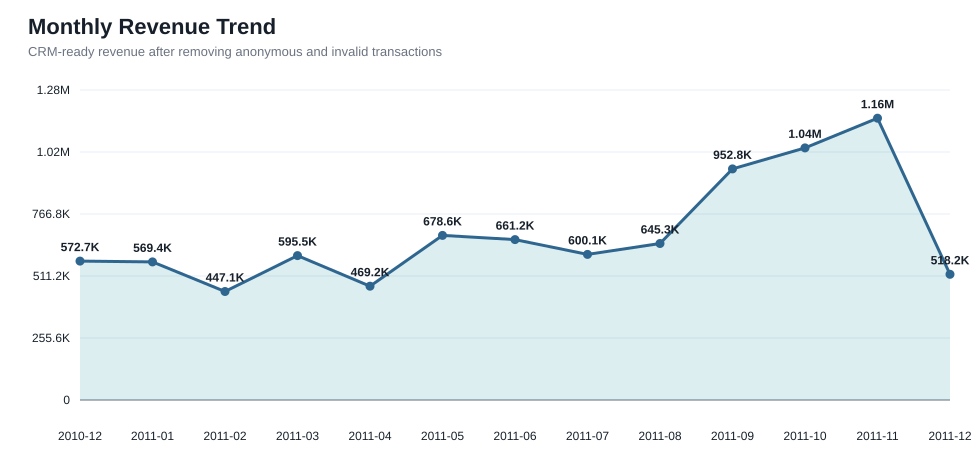

In [9]:
display(SVG(filename=str(figures_dir / "monthly_revenue.svg")))


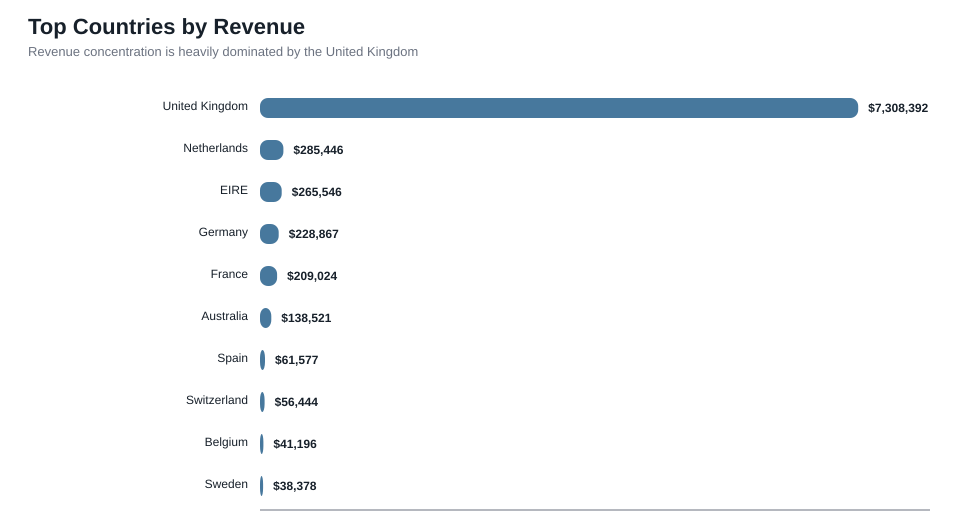

In [10]:
display(SVG(filename=str(figures_dir / "top_countries_revenue.svg")))


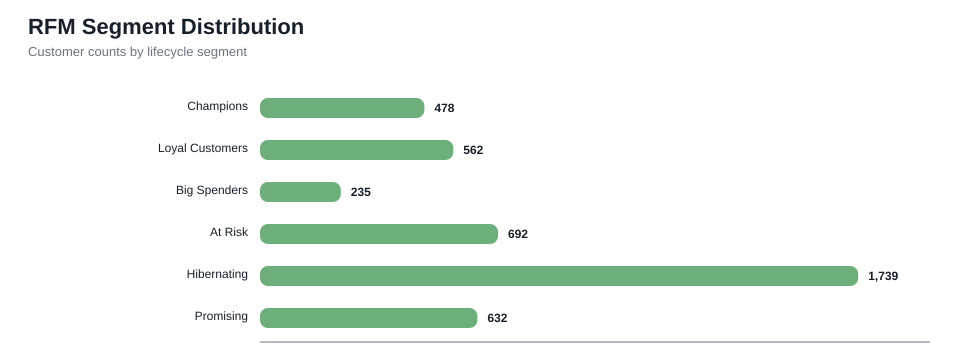

In [11]:
display(SVG(filename=str(figures_dir / "rfm_segment_counts.svg")))


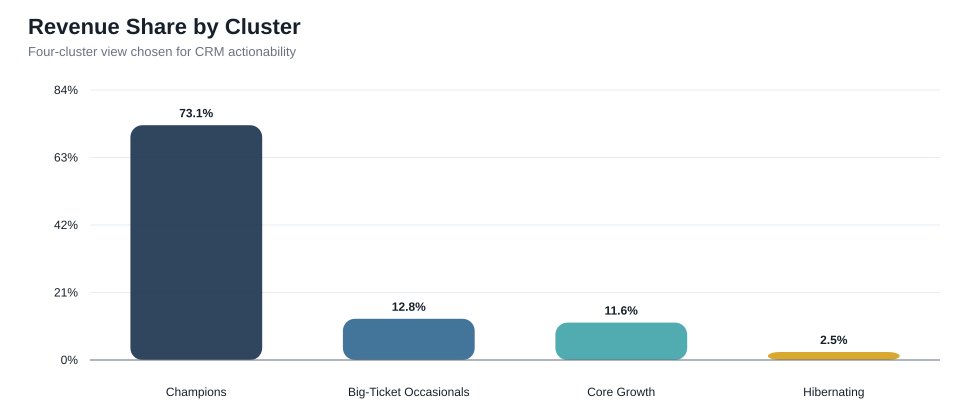

In [12]:
display(SVG(filename=str(figures_dir / "cluster_revenue_share.svg")))


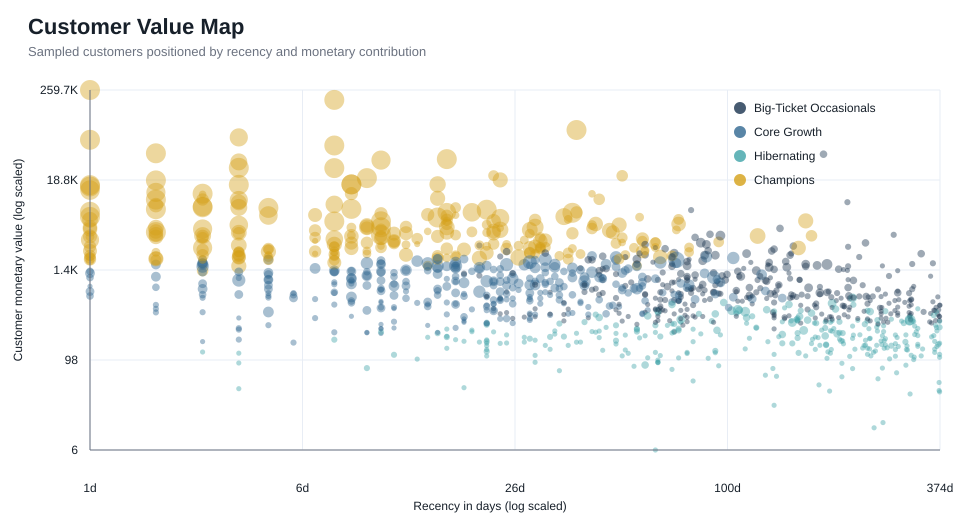

In [13]:
display(SVG(filename=str(figures_dir / "customer_value_map.svg")))


## 10. Business recommendations


In [14]:
recommendations = [
    "Prioritize Champions with loyalty, VIP access, and referral incentives.",
    "Move Core Growth customers toward repeat purchasing with bundle and cross-sell campaigns.",
    "Use win-back automation for Hibernating customers with time-limited reactivation offers.",
    "Design event-driven premium campaigns for Big-Ticket Occasionals instead of frequent discounting.",
]

for idx, item in enumerate(recommendations, start=1):
    print(f"{idx}. {item}")
print(f"Top RFM segment: {segment_summary.sort_values('Revenue', ascending=False).iloc[0]['RFM_Segment']}")
print(f"Top cluster: {cluster_profile.sort_values('RevenueSharePct', ascending=False).iloc[0]['ClusterName']}")
print(f"Peak revenue month: {monthly_revenue.sort_values('Revenue', ascending=False).iloc[0]['InvoiceMonth']}")


1. Prioritize Champions with loyalty, VIP access, and referral incentives.
2. Move Core Growth customers toward repeat purchasing with bundle and cross-sell campaigns.
3. Use win-back automation for Hibernating customers with time-limited reactivation offers.
4. Design event-driven premium campaigns for Big-Ticket Occasionals instead of frequent discounting.
Top RFM segment: Champions
Top cluster: Champions
Peak revenue month: 2011-11
